Read bug ledger csv

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read CSV file
df = pd.read_csv("logs/bug_repro_ledger_ipv6.csv")
print(f'My ledger file has {len(df)} number of rows')


My ledger file has 4 number of rows


In [4]:
display(df.head())

,timestamp,category,bug_type,exception,message,file,line,status,exit_code,timed_out,elapsed_sec,command,reason,input_hash,input_text,input_b64,crash_json,crash_bin
0,1775676245,parse_or_functional_bug_u1_3c4bcfdb31befcbeb5c...,invalidity,ParseException,IPv4 tokenization failure,pyparsing\core.py,1340,hang,-1,True,5.397851,./win-ipv6-parser.exe --ipstr 214.253.210.207,bug:invalidity,3c4bcfdb31befcbeb5c3a2006af0a49c,214.253.210.207,MjE0LjI1My4yMTAuMjA3,crashes/parse_or_functional_bug_u1_3c4bcfdb31b...,crashes/parse_or_functional_bug_u1_3c4bcfdb31b...
1,1775677477,parse_or_functional_bug_u2_4ef6e325c391af3360b...,invalidity,InvalidityBug,Malformed IPv4 structure,buggy_ipyparse\ipv6_mstv.py,93,hang,-1,True,5.867211,./win-ipv6-parser.exe --ipstr 12345::1,bug:invalidity,4ef6e325c391af3360bf6311871d690c,12345::1,MTIzNDU6OjE=,crashes/parse_or_functional_bug_u2_4ef6e325c39...,crashes/parse_or_functional_bug_u2_4ef6e325c39...
2,1775677946,other_output_u3_dcdad533c74eee980c43840dacc68e82,other,buggy_ipyparse.ipv6_mstv.ReliabilityBug,Incorrect token length.,buggy_ipyparse\ipv6_mstv.py,126,hang,-1,True,6.212265,./win-ipv6-parser.exe --ipstr 2001:::1,bug:bonus,dcdad533c74eee980c43840dacc68e82,2001:::1,MjAwMTo6OjE=,crashes/other_output_u3_dcdad533c74eee980c4384...,crashes/other_output_u3_dcdad533c74eee980c4384...
3,1775681853,parse_or_functional_bug_u4_3106fb3b0efb9d5aa7f...,invalidity,InvalidityBug,Malformed IPv4 structure,buggy_ipyparse\ipv6_mstv.py,132,hang,-1,True,5.653695,./win-ipv6-parser.exe --ipstr ffff:fff:ffff:ff...,bug:invalidity,3106fb3b0efb9d5aa7f5aa26765e1859,ffff:�fff:ffff:ffff:ffff:ffff:ffff:ffff:ffff,ZmZmZjqIZmZmOmZmZmY6ZmZmZjpmZmZmOmZmZmY6ZmZmZj...,crashes/parse_or_functional_bug_u4_3106fb3b0ef...,crashes/parse_or_functional_bug_u4_3106fb3b0ef...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    4 non-null      int64  
 1   category     4 non-null      str    
 2   bug_type     4 non-null      str    
 3   exception    4 non-null      str    
 4   message      4 non-null      str    
 5   file         4 non-null      str    
 6   line         4 non-null      int64  
 7   status       4 non-null      str    
 8   exit_code    4 non-null      int64  
 9   timed_out    4 non-null      bool   
 10  elapsed_sec  4 non-null      float64
 11  command      4 non-null      str    
 12  reason       4 non-null      str    
 13  input_hash   4 non-null      str    
 14  input_text   4 non-null      str    
 15  input_b64    4 non-null      str    
 16  crash_json   4 non-null      str    
 17  crash_bin    4 non-null      str    
dtypes: bool(1), float64(1), int64(3), str(13)
memory usage: 680.0 byt

In [6]:
# Number of unique bug types
bug_counts = df['bug_type'].value_counts()
print(bug_counts)

bug_type
invalidity    3
other         1
Name: count, dtype: int64


In [7]:
# Number of unique exceptions
exception_counts = df['exception'].value_counts()
print(exception_counts)

exception
InvalidityBug                              2
ParseException                             1
buggy_ipyparse.ipv6_mstv.ReliabilityBug    1
Name: count, dtype: int64


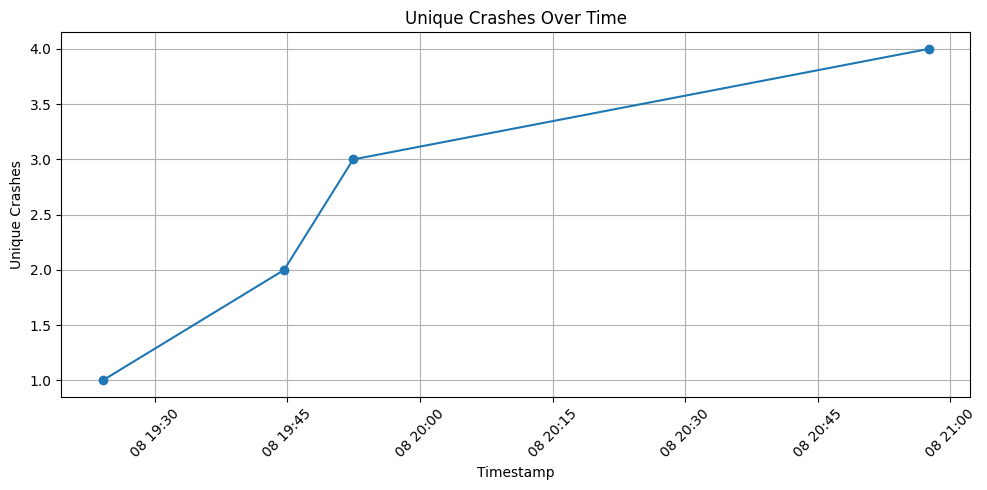

In [8]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Sort by timestamp
df = df.sort_values('timestamp')

# Cumulative count of crashes
df['Unique Crashes'] = range(1, len(df)+1)

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['timestamp'], df['Unique Crashes'], marker='o', linestyle='-')
plt.title("Unique Crashes Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Unique Crashes")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


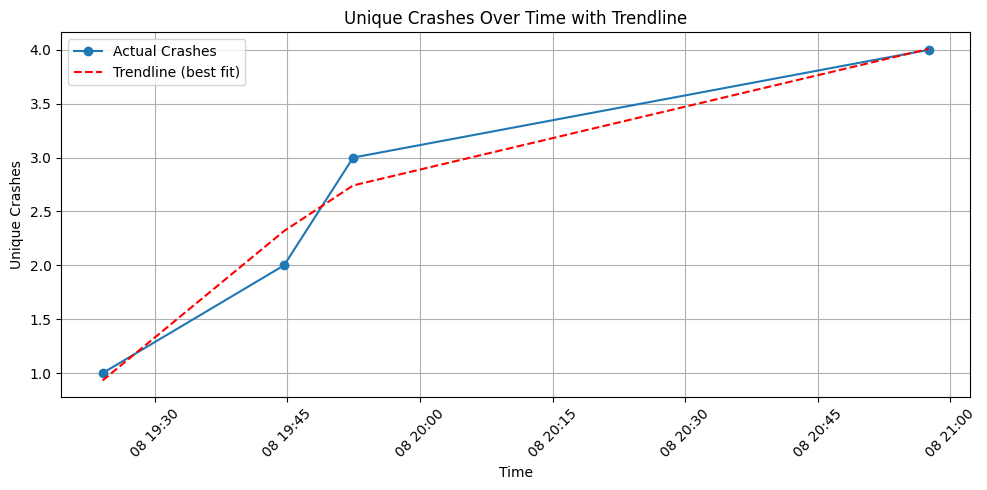

In [9]:
# Convert timestamp to numeric (seconds since first crash) for regression
df['elapsed_sec'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

# Fit a linear trendline
coeffs = np.polyfit(df['elapsed_sec'], df['Unique Crashes'], 2)  # degree 1 = linear
trendline = np.polyval(coeffs, df['elapsed_sec'])

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['timestamp'], df['Unique Crashes'], marker='o', linestyle='-', label='Actual Crashes')
plt.plot(df['timestamp'], trendline, color='red', linestyle='--', label='Trendline (best fit)')
plt.title("Unique Crashes Over Time with Trendline")
plt.xlabel("Time")
plt.ylabel("Unique Crashes")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df2 = pd.read_csv('logs/20260408_190356_linux-ipv4-parser.csv')

In [90]:
display(df2)

,timestamp,iteration,is_interesting,tier,reason,op_name,seed_text,mutated_text,seed_b64,mutated_b64,...,exit_code,timed_out,elapsed_sec,command,bug_type,exception,message,file,line,input_hash
0,1775645869,0,1,tier_2,new_coverage,warmup,236.239.214.209,236.239.214.209,MjM2LjIzOS4yMTQuMjA5,MjM2LjIzOS4yMTQuMjA5,...,0,False,1.052417,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,3037c129c3608415592f7f60b181178c
1,1775645870,1,1,tier_2,new_edge,warmup,253.242.253.198,253.242.253.198,MjUzLjI0Mi4yNTMuMTk4,MjUzLjI0Mi4yNTMuMTk4,...,0,False,1.019455,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,f83cb270b01cb545991f3173ec09b523
2,1775645871,2,1,tier_1,bug:validity,warmup,128.255.254.63,128.255.254.63,MTI4LjI1NS4yNTQuNjM=,MTI4LjI1NS4yNTQuNjM=,...,0,False,0.960440,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,validity,ParseException,"Expected '.', found '5' (at char 6), (line:1,...",pyparsing/core.py,1340.0,9f8588795d97908eb6f0551ce7c0cd65
3,1775645876,3,0,NaN,NaN,warmup,127.63.194.254,127.63.194.254,MTI3LjYzLjE5NC4yNTQ=,MTI3LjYzLjE5NC4yNTQ=,...,-1,True,4.951539,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,e5e97cefded3aaad7f4eb8189c8a93f6
4,1775645877,4,1,tier_2,new_edge,warmup,190.147.152.165,190.147.152.165,MTkwLjE0Ny4xNTIuMTY1,MTkwLjE0Ny4xNTIuMTY1,...,0,False,1.039271,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,NaN,NaN,NaN,NaN,NaN,3ee4d8d9f5fe686e2e9b564b0311a46f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1775646056,155,1,tier_2,new_coverage,mut_arithmetic,128.128.128.128,128128.128.128,MTI4LjEyOC4xMjguMTI4,MTI4FTEyOC4xMjguMTI4,...,0,False,1.035248,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,invalidity,ParseException,IPv4 tokenization failure,pyparsing/core.py,1340.0,1cbe83adfab9d749511883c48df2cb01
156,1775646057,156,1,tier_2,new_coverage,mut_bitflip,193.158.163.190,"193.158,163.190",MTkzLjE1OC4xNjMuMTkw,MTkzLjE1OCwxNjMuMTkw,...,0,False,0.986679,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,invalidity,ParseException,IPv4 tokenization failure,pyparsing/core.py,1340.0,f7e441c722d5ede2a50fe22ed17257c3
157,1775646058,157,1,tier_2,new_edge,mut_splice,21/31.20.59,21231.230.227,MjEvMzEuMjAuNTk=,MjEyMzEuMjMwLjIyNw==,...,0,False,1.019121,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,invalidity,ParseException,IPv4 tokenization failure,pyparsing/core.py,1340.0,b08b976e25febf306b16b9504ce41064
158,1775646059,158,1,tier_2,new_coverage,mut_string_whitespace_noise,20//255.255.255.2550.198.228.207,20//255.25\n\n5.255.2550.198.228.207,MjAvLzI1NS4yNTUuMjU1LjI1NTAuMTk4LjIyOC4yMDc=,MjAvLzI1NS4yNQoKNS4yNTUuMjU1MC4xOTguMjI4LjIwNw==,...,0,False,0.976651,../IPv4-IPv6-parser/bin/linux-ipv4-parser --ip...,validity,ParseException,"Expected '.', found '/' (at char 2), (line:1,...",pyparsing/core.py,1340.0,967b42cddfdc20478860f180902e0c7c
